In [2]:
from policy.queue.fifo import FIFOQueuePolicy
from experiments.replications import run_replications
table = run_replications(
    scenario={
        "n_piles": 2,
        "n_nozzles": 4,
        "n_bricks": 7,
        "p_brick": 25,
        "queue_capacity": 10,
        "lam": 5.0,
        "policy": FIFOQueuePolicy(),
    },
    n_reps=30,
    confidence=0.95,
)

In [4]:
#print(table.to_string(float_format=lambda x: f"{x:.4f}"))
print(table)

                                     mean       ci_low      ci_high
metric                                                             
finished EVs                   134.233333   132.185920   136.280746
dropped EVs                    131.233333   123.280144   139.186523
total energy delivered (kWh)  8283.855907  8265.754194  8301.957620
average L                       16.581683    16.461583    16.701783
average Q                        8.701425     8.592675     8.810175
avg wait time                   84.657051    82.538797    86.775305
max wait time                  138.164879   134.905214   141.424544
avg sys time                   166.719688   163.394686   170.044690


In [ ]:
from policy.queue.fifo import FIFOQueuePolicy
from experiments.replications import run_replications
table = run_replications(
    scenario={
        "n_piles": 2,
        "n_nozzles": 4,
        "n_bricks": 7,
        "p_brick": 25,
        "queue_capacity": 10,
        "lam": 5.0,
        "policy": FIFOQueuePolicy(),
    },
    n_reps=30,
    confidence=0.95,
)
print(table)

In [1]:
import numpy as np
from env.charging_env import ChargingStationEnv
from policy.queue.fifo import FIFOQueuePolicy

env = ChargingStationEnv(
    n_piles=2,
    n_nozzles=4,
    n_bricks=7,
    p_brick=25,
    queue_capacity=10,
    lam=5.0,
)

obs, info = env.reset(seed=42)
done = False
rng = np.random.default_rng(1)
policy = FIFOQueuePolicy()
total_reward = 0.0

while not done:
    mask = env.action_masks()
    ev, pile_id = policy.decide(obs, mask, rng, env.engine.station)
    obs, reward, done, _, info = env.step(pile_id, ev=ev)
    total_reward += reward

print(f"Finished EVs: {len(env.engine.metrics.finished_evs)}")
print(f"Dropped EVs: {len(env.engine.metrics.dropped_evs)}")
print(f"Avg L: {env.engine.metrics.average_L():.3f}")
print(f"Avg Q: {env.engine.metrics.average_Q():.3f}")
print(f"Total reward: {total_reward:.3f}")
print(f"Sim time: {env.engine.current_time:.1f}")


Finished EVs: 136
Dropped EVs: 148
Avg L: 16.380
Avg Q: 8.600
Total reward: -19783.649
Sim time: 1440.0


In [3]:
import numpy as np
from env.charging_env import ChargingStationEnv
from policy.queue.fifo import FIFOQueuePolicy

env = ChargingStationEnv(
    n_piles=2,
    n_nozzles=4,
    n_bricks=7,
    p_brick=25,
    queue_capacity=10,
    lam=5.0,
)

obs, info = env.reset(seed=42)
done = False
rng = np.random.default_rng(1)
policy = FIFOQueuePolicy()
total_reward = 0.0

while not done:
    mask = env.action_masks()
    ev, pile_id = policy.decide(obs, mask, rng, env.engine.station)
    obs, reward, done, _, info = env.step(pile_id, ev=ev)
    total_reward += reward

print(f"Finished EVs: {len(env.engine.metrics.finished_evs)}")
print(f"Dropped EVs: {len(env.engine.metrics.dropped_evs)}")
print(f"Avg L: {env.engine.metrics.average_L():.3f}")
print(f"Avg Q: {env.engine.metrics.average_Q():.3f}")
print(f"Total reward: {total_reward:.3f}")
print(f"Sim time: {env.engine.current_time:.1f}")


Finished EVs: 136
Dropped EVs: 148
Avg L: 16.380
Avg Q: 8.600
Total reward: -19783.649
Sim time: 1440.0


In [5]:
from metrics.validate import validate_episode, report_queueing_laws

summary = env.engine.metrics.queueing_summary(env.engine.current_time)
waits, services, sojourns = env.engine.metrics.finished_time_arrays()
rep_val = validate_episode(env, verbose=True)
reo_q = report_queueing_laws(env, verbose=True)


=== Episode validation ===
  arrived=302, finished=136, dropped=148, queued=10, plugged=8
  [PASS] Finished: s_current ~= s_f: ok for all finished EVs
  [PASS] Finished: energy_received ~= c_b*(s_f-s_i)/HR2MIN: ok for all finished EVs
  [PASS] Finished: energy_received ~= energy_received_2: ok for all finished EVs
  [PASS] Finished: departure_time >= service_start_time >= arrival_time: ok for all finished EVs
  [PASS] Finished: pile_tracker / nozzle_id_tracker set: ok for all finished EVs
  [PASS] Finished: p_act <= p_req in charge_trace: ok for all finished EVs
  [PASS] Dropped: never got service_start_time / empty charge_trace: ok for all dropped EVs
  [PASS] arrived = finished + dropped + queued + plugged: 302 vs 136+148+10+8=302

=== Queueing laws ===
  T=1440.0 min, finished=136, c=8 servers
  lambda_eff=0.094444 /min
  E[W]=161.6940 min, E[W_q]=82.1349 min, E[S]=79.5591 min
  Little L = lambda_eff * W :  theory=15.2711  sim=16.3798  |diff|=1.1087
  Little Q = lambda_eff * W_q:  

In [4]:
EVs = env.engine.metrics.arrived_evs

In [5]:
EVs[2].s_f

0.8343708377228134

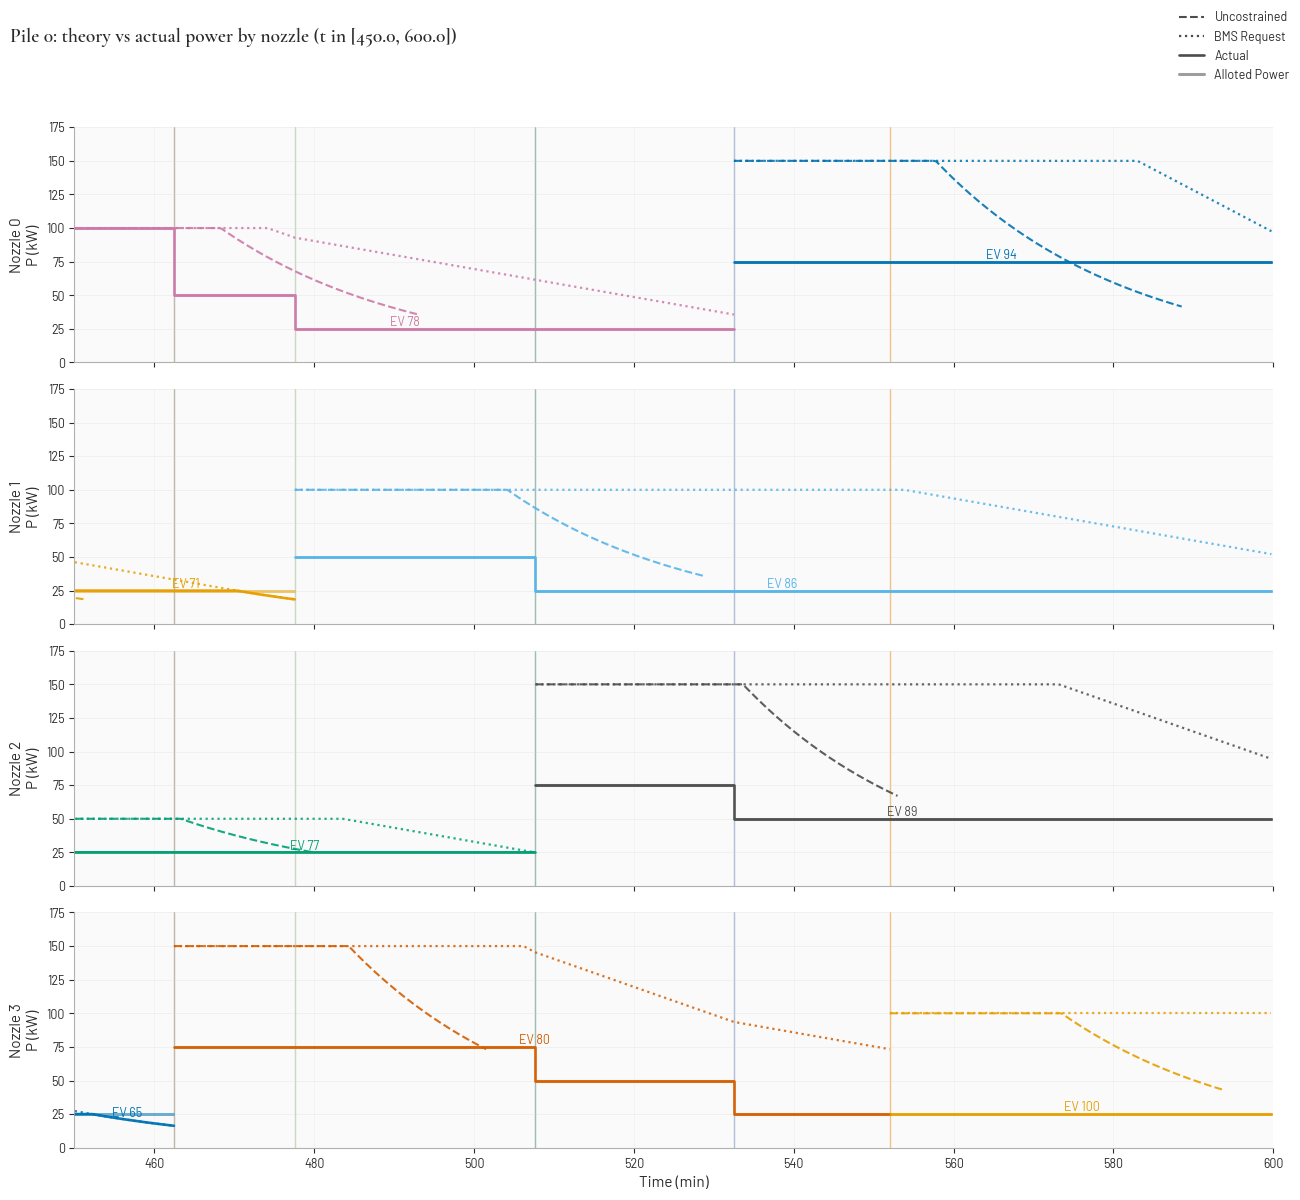

In [ ]:
from visualization.pile_power import plot_pile_nozzle_power
import matplotlib.pyplot as plt

fig = plot_pile_nozzle_power(
    env, 0,
    t_start = 450,
    t_end=600,
    show_theory=True,      # default
    show_sim_bms=True,     # optional overlay
    show_actual=True,
    show_legend=True,
    label_theory="Uncostrained", # Power if this EV always got its full BMS request
    label_sim_bms="BMS Request",          # Max power the battery would accept at that SoC
    label_actual="Actual",       # Power the pile delivered
    label_charge_steps="Alloted Power", # Allotted power — brick share held between redistributions.
    show_charge_change_lines=True,   # horizontal p_act plateaus between trace samples
    show_charge_change_vlines=False,
    show_trace_labels=False,          # P, t, s, n_bricks at each charge_trace point
    title=None,              # default template with pile_id / window
    show_event_lines=True,
    event_line_alpha=0.25,
    show_ev_ids=True,
)
fig

Plotting EV 10 (pile 0, nozzle 0), charts=['P-S', 'T-S', 'P-T'], trace_len=5
Plotting EV 11 (pile 1, nozzle 0), charts=['P-S', 'T-S', 'P-T'], trace_len=3
Plotting EV 12 (pile 0, nozzle 1), charts=['P-S', 'T-S', 'P-T'], trace_len=5
Plotting EV 13 (pile 1, nozzle 0), charts=['P-S', 'T-S', 'P-T'], trace_len=6
Plotting EV 14 (pile 0, nozzle 0), charts=['P-S', 'T-S', 'P-T'], trace_len=5


[<Figure size 1620x400 with 3 Axes>,
 <Figure size 1620x400 with 3 Axes>,
 <Figure size 1620x400 with 3 Axes>,
 <Figure size 1620x400 with 3 Axes>,
 <Figure size 1620x400 with 3 Axes>]

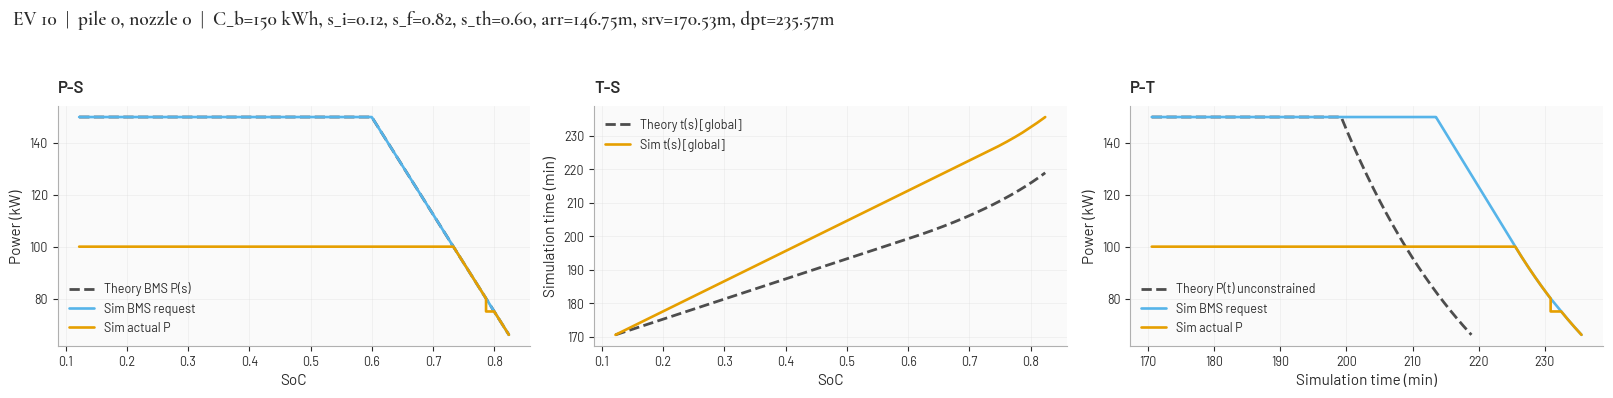

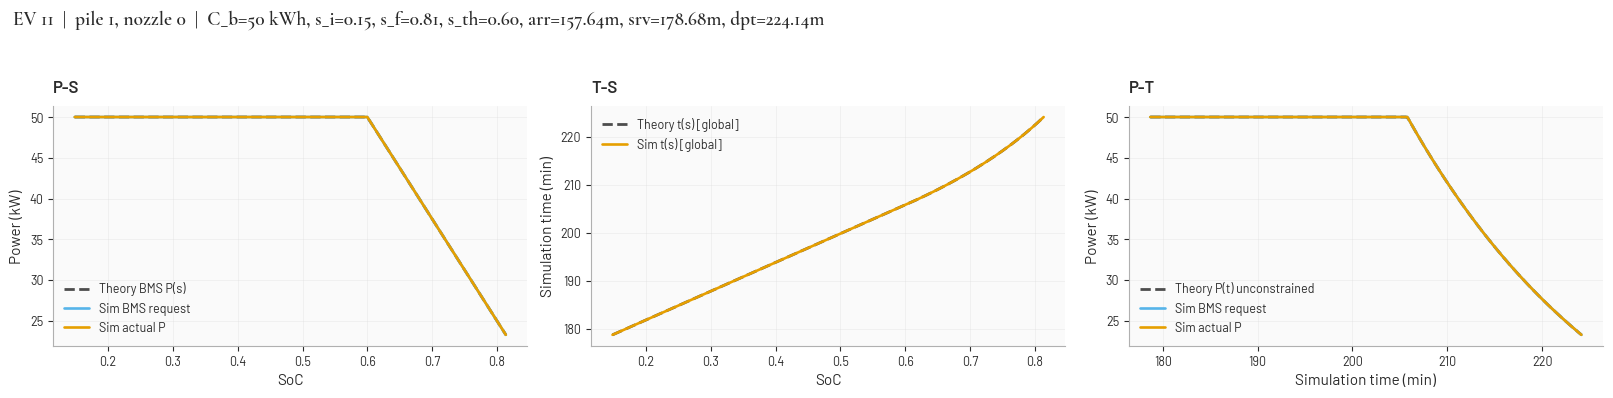

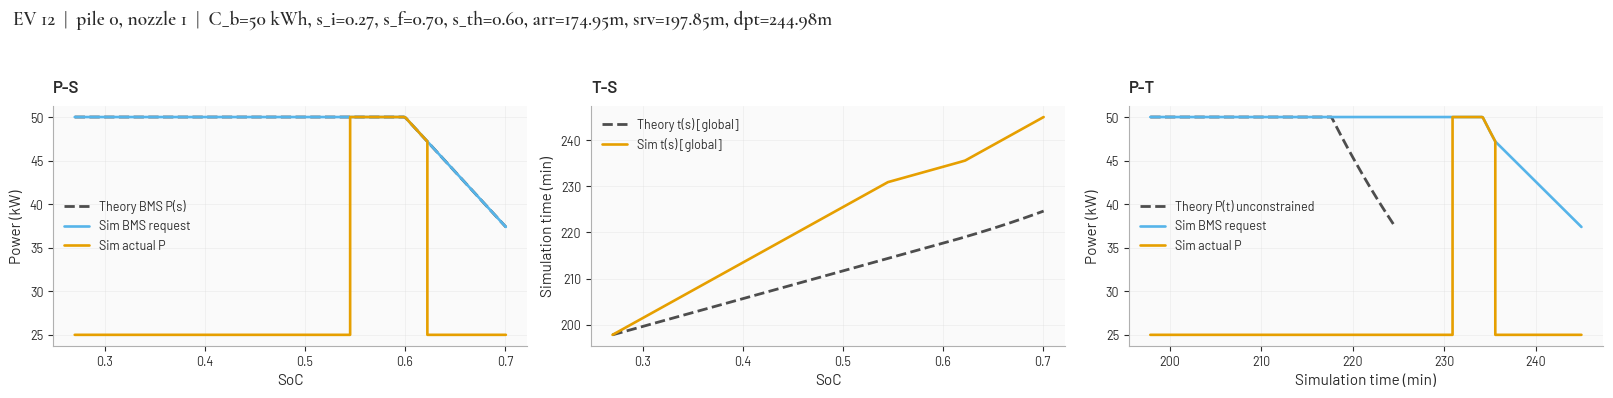

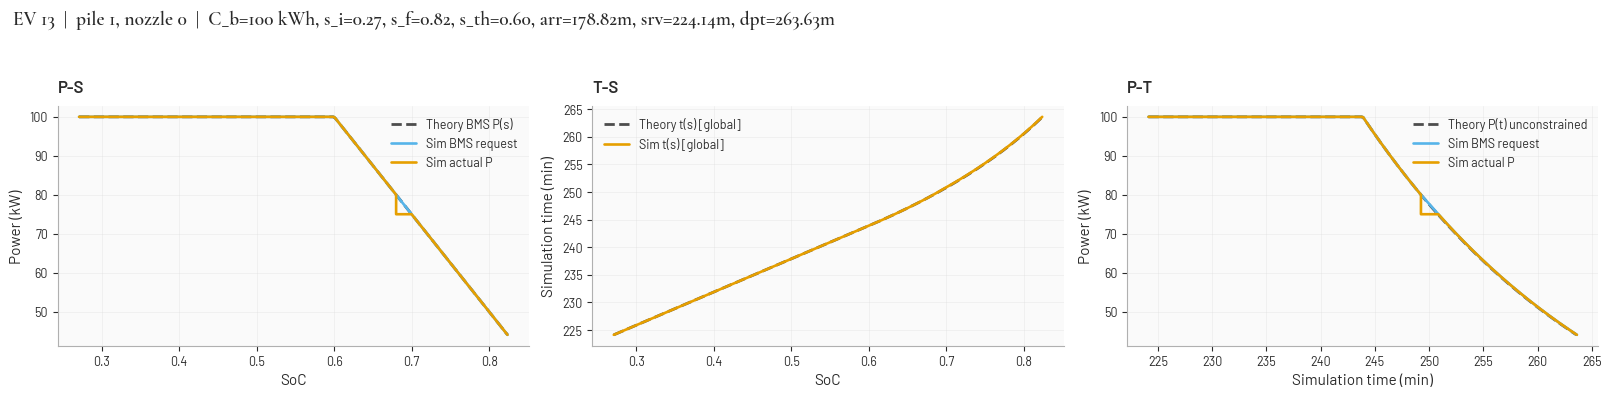

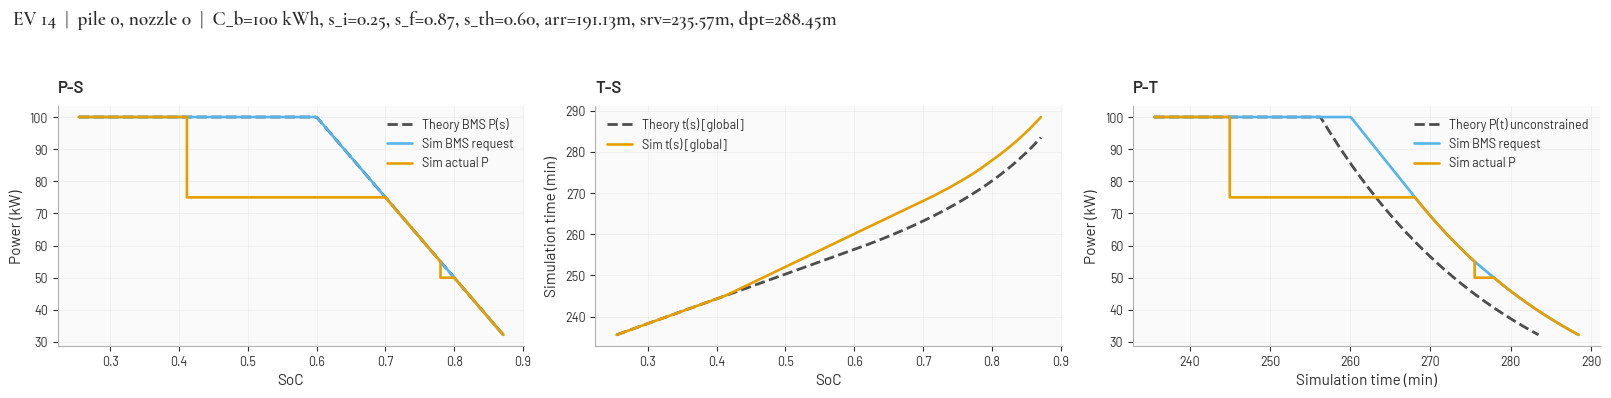

In [14]:
from visualization.ev_curves import plot_ev_theory_vs_sim
import matplotlib.pyplot as plt

figs = plot_ev_theory_vs_sim(
    env,
    ev_ids=[_ + 10 for _ in range(5)],
    charts=["P-S", "T-S", "P-T"],
    show_theory=True,
    show_sim_bms=True,
    show_sim_actual=True,
    show_recorded_samples=False,
    label_theory=None,       # defaults per chart if None
    label_sim_bms=None,
    label_sim_actual=None,   # on T-S → "Sim t(s) [global]"
    label_recorded=None,
)
figs
